In [2]:
%cd ../.
import sys
# sys.path.append('../keys'); # sys.path.append('./.')

/home/gtamo/MS_ML


In [3]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from xgboost import XGBClassifier
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats

# user defined modules
import python.Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import python.Molecule as M
import python.ML_Reg as ML_Reg
import python.ML_Class as ML_Class
from python.MolViz3D import MolViz3D
import python.Statistics_tools as stats_tools
# from tdc.multi_pred import DTI

> could not load openbabel


# FUNCTIONS

# MAIN

## From processed data 

#### 0. Data Exploration and formatting

In [4]:
## params
active_c = '#008bfb' # "#3B85C1"
silent_c = '#ff0051'

In [5]:
%%time
MS = pd.read_csv('data/MS/CDD CSV Export - 2026-04-29 06h13m33s.csv').drop(['CDD Number'],axis=1)
MS = MS[MS['MSData - Proteomics activities: Source']=='SERAC'] # 
MS['MSData - Proteomics activities: Date'] = pd.to_datetime(MS['MSData - Proteomics activities: Date'])
MS['MSData - Proteomics activities: MSPlate'].unique()

# remove plate 12 data (from Daniela)
MS = MS[~MS['MSData - Proteomics activities: MSPlate'].isin(['Pw33','Plate12']) ]

# if a compound is tested multiple times, get only by latest date
MS = MS.sort_values('MSData - Proteomics activities: Date',ascending=False).reset_index()
MS = MS.groupby('Molecule Name').first().reset_index()

print('>', len(MS['Molecule Name'].unique()),'unique compounds')
print('> Ligase(s)',list(MS['MSData - Proteomics activities: Ligase'].unique()))
print('> Cellline',list(MS['MSData - Proteomics activities: Cell line'].unique()))
print('> dim:',MS.shape)
MS.head(2)

> 1598 unique compounds
> Ligase(s) ['FBXO31']
> Cellline ['HepG2']
> dim: (1598, 31)
CPU times: user 70.7 ms, sys: 11.4 ms, total: 82.2 ms
Wall time: 93.8 ms


,Molecule Name,index,SMILES,Molecular weight (g/mol),log P,Topological polar surface area (Å²),Synonyms,Subseries,PROTAC Target,PROTAC Parent,...,MSData - Proteomics activities: Cell line,MSData - Proteomics activities: Sample Condition,MSData - Proteomics activities: Incubation time (h),MSData - Proteomics activities: Concentration (uM),MSData - Proteomics activities: MSPlate,MSData - Proteomics activities: Screen,MSData - Proteomics activities: Nr. Down,MSData - Proteomics activities: Cmpd Activity,MSData - Proteomics activities: Genes Down,MSData - Proteomics activities: Date
0,SRB-0000385,1316,O=C(OCC1C2=CC=CC=C2C2=CC=CC=C12)N1[C@H]2CC3=CC...,410.473,4.2,58.6,NaN,AJ,NaN,NaN,...,HepG2,WildType,24.0,10.0,Pw79,1.0,3.0,Low (2-10),MPZL3;TMEM39B;SUFU,2026-04-15
1,SRB-0000401,3179,O=C1NC[C@H]2C3=CC=CC=C3C[C@@H]1N2C(=O)C,230.267,0.3,49.4,SERAJ000003,AJ,NaN,NaN,...,HepG2,WildType,24.0,10.0,Plate24,1.0,0.0,Silent,NaN,2025-06-11


In [6]:
## find new of silent compounds:
MS['label'] = (MS['MSData - Proteomics activities: Nr. Down'] > 0 ) * 1
baseline = MS['label'].sum() / MS.shape[0]
print('> fraction of active compounds:', round(baseline,2))

> fraction of active compounds: 0.69


#### 1. ML to predict Genreral activity

In [7]:
# get data and rename variables:
data = MS[['Molecule Name','SMILES','MSData - Proteomics activities: Date','label']].rename(columns={'Molecule Name':'compound','SMILES':'smiles','MSData - Proteomics activities: Date':'date'})
data.head(3)


,compound,smiles,date,label
0,SRB-0000385,O=C(OCC1C2=CC=CC=C2C2=CC=CC=C12)N1[C@H]2CC3=CC...,2026-04-15,1
1,SRB-0000401,O=C1NC[C@H]2C3=CC=CC=C3C[C@@H]1N2C(=O)C,2025-06-11,0
2,SRB-0000433,O=C1NC[C@H]2C3=CC=CC=C3C[C@@H]1N2C(=O)CC,2026-04-23,1


In [8]:
%%time
properties = rdkit_tools.compute_properties_from_smiles(data)
MF         = rdkit_tools.get_MF_bits_from_df(data,nBits=2048)
ML_data = pd.merge(MF,properties)
ML_data = pd.merge(ML_data, data[['compound','smiles','label','date']], on='compound')
ML_data.head(2)

CPU times: user 1.88 s, sys: 0 ns, total: 1.88 s
Wall time: 1.9 s


,compound,F0,F1,F2,F3,F4,F5,F6,F7,F8,...,F2047,Hba,Hbd,MW,TPSA,LogP,NRB,smiles,label,date
0,SRB-0000385,0,0,0,0,0,0,0,0,0,...,0,3.0,1.0,410.163043,58.64,4.0333,2.0,O=C(OCC1C2=CC=CC=C2C2=CC=CC=C12)N1[C@H]2CC3=CC...,1,2026-04-15
1,SRB-0000401,0,0,0,0,0,0,0,0,0,...,0,2.0,1.0,230.105528,49.41,0.6307,0.0,O=C1NC[C@H]2C3=CC=CC=C3C[C@@H]1N2C(=O)C,0,2025-06-11


In [9]:
## CHeck ML for leakage and other possible issues
stats_tools.check_ML_data(ML_data)

  [PASS] shape: 1598 rows x 2058 cols
  [PASS] no duplicate 'compound'
  [PASS] no duplicate SMILES
  [PASS] label is binary, positive fraction = 0.69
  [PASS] 2054 feature columns, all numeric
  [PASS] no NaN in features
  [PASS] no +/-inf in features
  [WARN] 229 constant (zero-variance) feature columns

PASS (0 failure(s))


True

In [ ]:
## send data to autoresearch
from autoresearch.run_one import cache_ML_data
cache_ML_data(ML_data)        # writes autoresearch/logs/ML_data.pkl


In [ ]:
## test autoresearch:
from autoresearch.run_one import run_one, append_log, update_best_if_improved, load_ML_data
ML_data = load_ML_data()
change = {
    'id':       'baseline_xgb',
    'desc':     'Reproduce the notebook XGB baseline',
    'model':    {'cls': 'XGBClassifier',
                 'params': {'n_estimators': 200, 'max_depth': 3,
                            'learning_rate': 0.05, 'colsample_bytree': 1.0,
                            'min_child_weight': 1, 'scale_pos_weight': 1}},
    'features': 'all', 'cutoff': 0.5, 'folds': 5,
}
rec = run_one(ML_data, change)
append_log(rec)
update_best_if_improved(rec)
rec

KstestResult(statistic=0.1541894418280802, pvalue=1.4090733021378117e-07, statistic_location=433.11076995999997, statistic_sign=-1)
TtestResult(statistic=4.781618784508372, pvalue=1.8990551108232813e-06, df=1596.0)


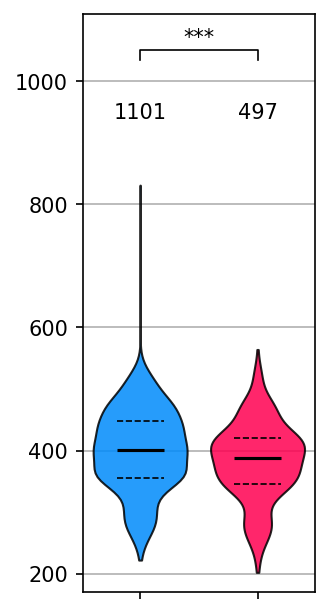

In [10]:
## violin/boxplot of properties vs activity:
l = 'MW'
label1 = ML_data[ML_data['label']==1][l].values
label0 = ML_data[ML_data['label']==0][l].values
print(stats.kstest(label1, label0))
print(stats.ttest_ind(label1, label0))

stats_tools.plot_nice_violinplot([label1,label0],colors=[active_c,silent_c],height=5,width=2,dpi=150,show_stars=True)

In [11]:
### Analysis on vectors:
vec_df = pd.read_csv('data/MS/CDD CSV Export - 2026-04-29 05h13m36s.csv').rename(columns={'Molecule Name':'compound'})[['compound','Largest_Vector','Largest_Vector_Lenght']]
vec_df = pd.merge(vec_df,ML_data[['compound','label']]).drop_duplicates()



In [12]:
vec_df.head(2)

,compound,Largest_Vector,Largest_Vector_Lenght,label
0,SRB-0007258,v7,4.0,1
1,SRB-0007219,v7,6.0,0


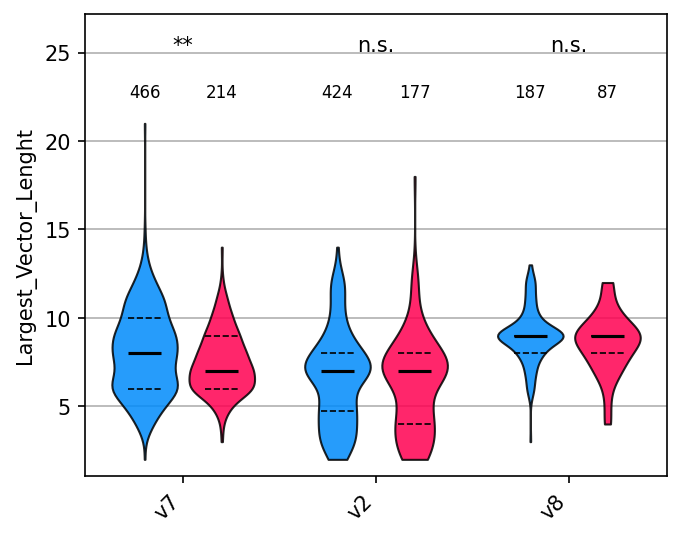

In [13]:
## paired violin plot — Largest_Vector_Lenght by label, within the top-3 most populated Largest_Vector groups
# join label inline so this cell doesn't depend on vec_df already having it
vec_df_lab = pd.merge(
    vec_df[['compound', 'Largest_Vector', 'Largest_Vector_Lenght']],
    data[['compound', 'label']], on='compound', how='inner'
)

stats_tools.plot_grouped_violinplot(
    vec_df_lab,
    group_col='Largest_Vector', subgroup_col='label', value_col='Largest_Vector_Lenght',
    top_n_groups=3,
    subgroups=[1, 0],                          # active first, silent second
    colors=[active_c, silent_c],
    show_stars=True, stars_test='ks',
    height=4, width=5, dpi=150,
)

In [ ]:
# %%time
## plot chemical space of silent vs non-silent
# compute distance matrix:
# dmat = rdkit_tools.get_RDKiTTanimoto_distance_matrix(MF, MF)

In [10]:
## tsne plot of chemical space, colored by activity label

from numba import njit
@njit(fastmath=True, cache=True)
def tanimoto_dist_numba(a, b):
    dot = np.dot(a, b)
    return 1.0 - dot / (a.sum() + b.sum() - dot + 1e-12)

embedding = oTSNE(metric=tanimoto_dist_numba,
                  neighbors='pynndescent',     # ← required for callables
                  n_jobs=-1,
                  n_components=2,
                  perplexity=30,
                  random_state=42).fit(MF.drop('compound', axis=1).values.astype(np.float32))

# TSNE w/ precomputed metric needs a symmetric, non-negative, zero-diagonal matrix
# embedding = TSNE(
#     n_components=2,
#     metric='precomputed',
#     init='random',
#     perplexity=30,
#     random_state=42,
# ).fit_transform(dmat)

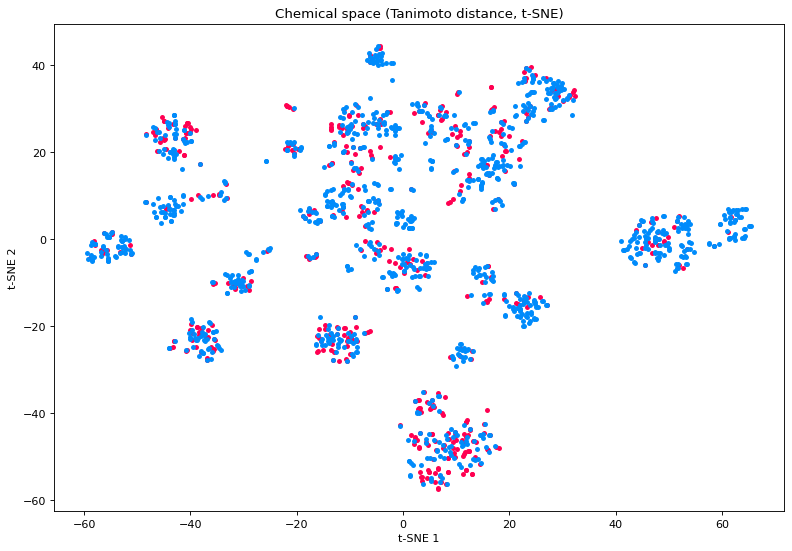

In [17]:
# look up label per compound, aligned to dmat row order
labels = data['label'].values

fig, ax = plt.subplots(figsize=(10, 7), dpi=80)
# plot silent first so active sits on top
for lab, color, name in [(0, silent_c, 'silent (label=0)'),
                          (1, active_c, 'active (label=1)')]:
    mask = labels == lab
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                s=20, alpha=1, c=color, label=name, edgecolors='black',linewidths=0.0)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2') # plt.legend();
plt.title('Chemical space (Tanimoto distance, t-SNE)')
plt.tight_layout()

In [7]:
## XGB parameter grid search:
# xgb_params = {
#     'n_estimators':     [100, 300],
#     'max_depth':        [3, 5, 7],
#     'learning_rate':    [0.01, 0.05, 0.1],
#     'subsample':        [0.7, 0.85, 1.0],
#     'colsample_bytree': [0.5, 0.7, 1.0],
#     'min_child_weight': [1, 5, 10],
#     'gamma':            [0, 0.1, 1.0],
#     'reg_alpha':        [0, 0.1, 1.0],
#     'reg_lambda':       [1, 5, 10],
#     'scale_pos_weight': [1, 5, 6.7],   # ~majority/minority ratio for your imbalance
# }

# xgb_params = {
#     'n_estimators':     [100, 500],
#     'max_depth':        [3, 5, 7],
#     'learning_rate':    [0.05, 0.1],
#     'colsample_bytree': [0.5, 0.7, 1.0],
#     'min_child_weight': [1, 5],
#     'scale_pos_weight': [1, 6],
#     # leave defaults for: subsample=1, gamma=0, reg_alpha=0, reg_lambda=1
# }

# res_search = ML_Class.Model_gridsearch_parpool_clf(ML_data.drop(['compound','date'],axis=1), 'XGBClassifier', xgb_params, col2scale_=[], nprocs=10,
#                                   multiPtype='joblib', scoring='roc_auc', cv=3)

In [ ]:
# res_search

In [18]:
# model = RandomForestClassifier(n_estimators=100,n_jobs=-1,random_state=0) # 
params = {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}
model = XGBClassifier(**params,n_jobs=-1,random_state=42)
trained_model, df_pred =  ML_Class.run_K_Fold_Xval_Classification(ML_data, ID='compound', model=model,
                                   folds=5, col_to_rm=['label', 'compound','smiles','date'], v=True, ctf=0.5, impute_by_mean=False)

# Naive baseline: predicts class proportions ⇒ ROC AUC ≈ 0.5 by construction.
# Useful for sanity-checking the CV pipeline and contextualising F1/MCC/PPV.
naive_model = DummyClassifier(strategy='stratified', random_state=42)
_, df_pred_naive = ML_Class.run_K_Fold_Xval_Classification(ML_data, ID='compound', model=naive_model,
                                   folds=5, col_to_rm=['label', 'compound','smiles','date'], v=False, ctf=0.5, impute_by_mean=False)

> feature dim: (1598, 2054)


 20%|██        | 1/5 [00:17<01:08, 17.00s/it]

-----------------------------------------
> Fold 1 Accuracy: 0.72, F1: 0.83, Roc_auc: 0.67, PR_auc: 0.81,
>> True negative (False negative):  23 ( 21 )
>> True positive (False positive):  209 ( 67 )


 40%|████      | 2/5 [00:26<00:38, 12.73s/it]

-----------------------------------------
> Fold 2 Accuracy: 0.68, F1: 0.78, Roc_auc: 0.66, PR_auc: 0.78,
>> True negative (False negative):  28 ( 25 )
>> True positive (False positive):  188 ( 79 )


 60%|██████    | 3/5 [00:29<00:16,  8.30s/it]

-----------------------------------------
> Fold 3 Accuracy: 0.69, F1: 0.80, Roc_auc: 0.67, PR_auc: 0.80,
>> True negative (False negative):  24 ( 19 )
>> True positive (False positive):  197 ( 80 )


 80%|████████  | 4/5 [00:32<00:06,  6.11s/it]

-----------------------------------------
> Fold 4 Accuracy: 0.70, F1: 0.81, Roc_auc: 0.67, PR_auc: 0.80,
>> True negative (False negative):  22 ( 14 )
>> True positive (False positive):  201 ( 82 )


100%|██████████| 5/5 [00:34<00:00,  6.98s/it]


-----------------------------------------
> Fold 5 Accuracy: 0.73, F1: 0.83, Roc_auc: 0.71, PR_auc: 0.85,
>> True negative (False negative):  28 ( 21 )
>> True positive (False positive):  206 ( 64 )

>>> Global accuracy: 0.70, F1: 0.81, ROC_AUC: 0.68, PR_AUC: 0.81


100%|██████████| 5/5 [00:00<00:00, 43.33it/s]


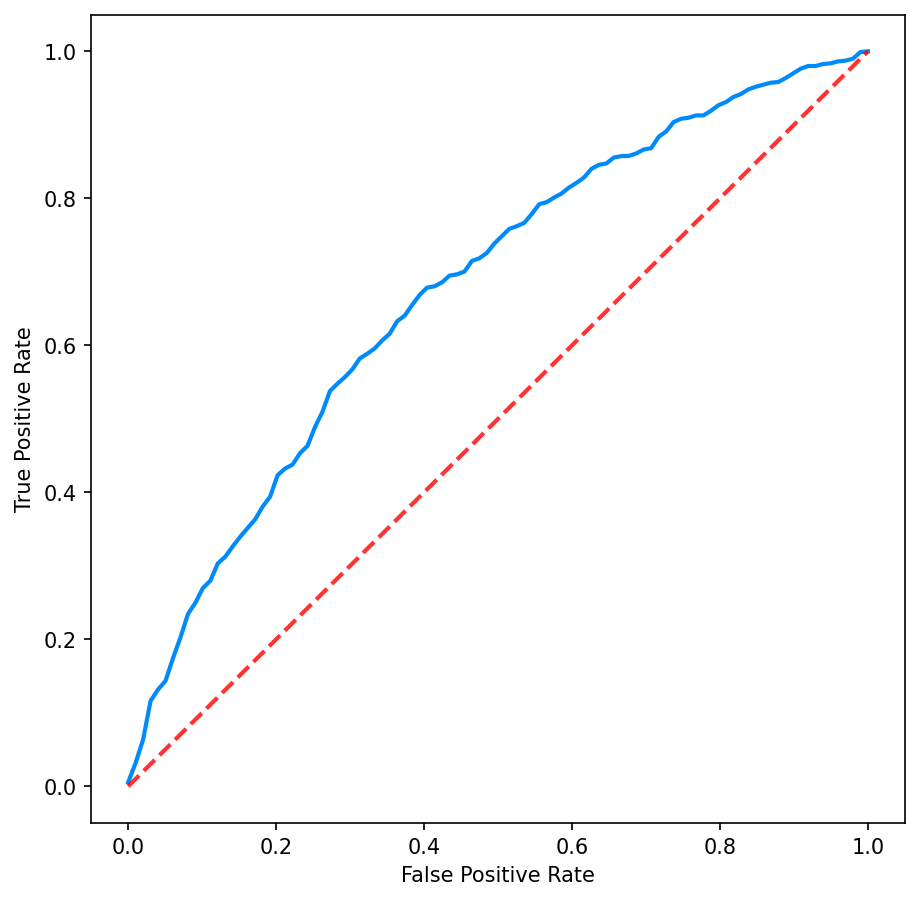

In [23]:
roc_df = ML_Class.plot_roc_curve(
    [df_pred],
    c=[active_c],
    l=['XGB'],
    metric2show=['roc_auc'],dpi=150,legend=False
)

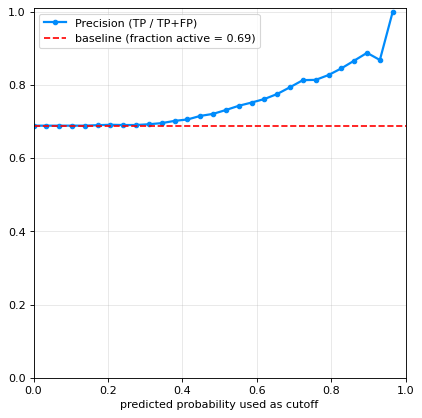

In [16]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(df_pred, npts=30, plot=True,baseline=baseline,dpi=80)

##### 2.1 Predict enumeration set

In [ ]:
# get_smiles_df_from_enum has been moved to python/Rdkit_tools.py
# (call as rdkit_tools.get_smiles_df_from_enum)

In [17]:
## Fit best model to the training dataset
params = {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'scale_pos_weight': 1}
final_model = XGBClassifier(**params,n_jobs=-1,random_state=42)

# Train the model on training data
train_X   = ML_data.drop(['label', 'compound','smiles','date'],axis=1)
train_y   = ML_data['label']
feat_cols = list(train_X.columns)
final_model.fit(train_X, train_y)

# record probabilities associated with each prediction
# probas = rf.predict_proba(test_X)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

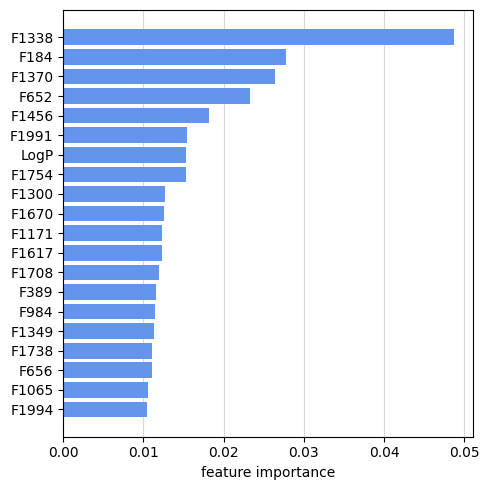

In [21]:
## variable importance — top features used by the trained XGB classifier
to_drop = ['label', 'compound', 'smiles', 'date']
fi = ML_Class.get_important_variables(
    XGBClassifier(**params, n_jobs=-1, random_state=42),
    ML_data, to_drop=to_drop,
    plot=True, n=20, dpi=100,
)
# fi.head(10)

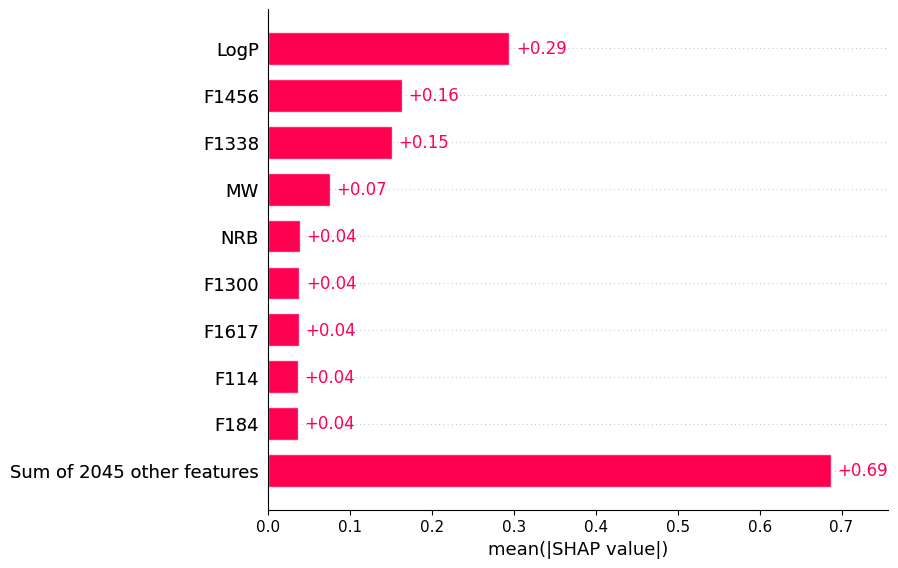

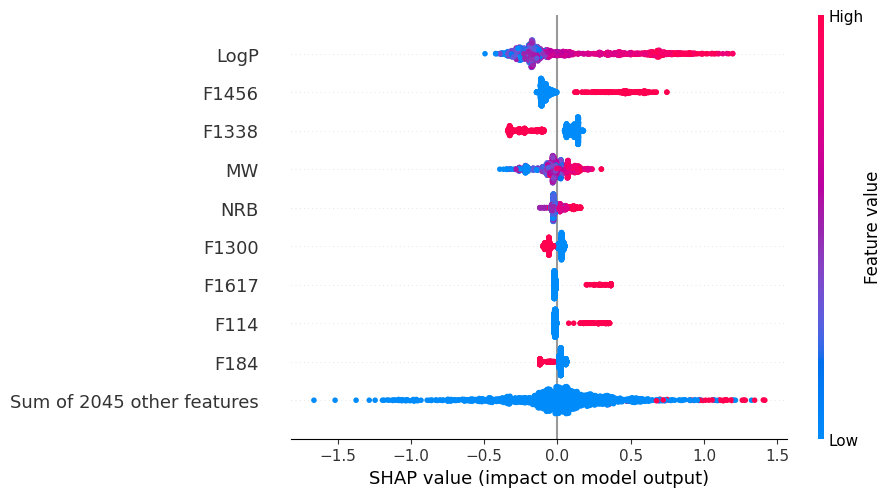

compound=SRB-0002897, p(active)=0.966


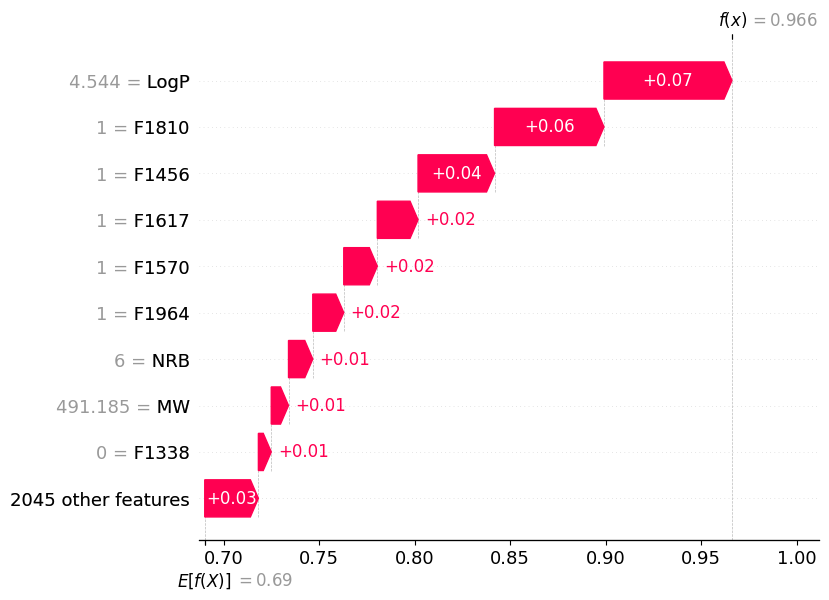

In [29]:
## SHAP analysis — feature contributions to p(active)
## requires shap in the active env:  pip install "shap<0.47"
shap_values, shap_p = ML_Class.shap_analysis_xgb(
    final_model, train_X,
    compound_ids=ML_data['compound'].values,
    which='top', max_display=10,
)

In [25]:
outpathcsv = 'output/enumeration/20260429/csv/'; os.makedirs(outpathcsv, exist_ok=True)
outpathsdf = 'output/enumeration/20260429/sdf/'; os.makedirs(outpathsdf, exist_ok=True)
enumpath = 'data/enumeration/20260427/'
enum_fs = glob(enumpath+'*')

In [ ]:
## Predict probabilities for all sdf files!
for enum_f in tqdm(enum_fs):
    fname = Path(enum_f).stem
    # print('>', fname)

    # convert sdf to smiles and extract relevant fields/columns
    enum_df = rdkit_tools.get_smiles_df_from_enum(enum_f)
    enum_df['compound']  = enum_df['R1_Code'] + '_' + enum_df['R2_Code']
    enum_df['filename']  = fname

    # compute ML features
    properties_e = rdkit_tools.compute_properties_from_smiles(enum_df)
    MF_e         = rdkit_tools.get_MF_bits_from_df(enum_df, nBits=2048)
    enum_features = pd.merge(MF_e, properties_e, on='compound').reset_index(drop=True)
    enum_X = enum_features.drop('compound', axis=1).reindex(columns=feat_cols, fill_value=0)

    enum_features['predicted_probas'] = final_model.predict_proba(enum_X)[:, 1]
    enum_df = (pd.merge(enum_df, enum_features[['compound', 'predicted_probas']],on='compound', how='left')
                 .sort_values('predicted_probas', ascending=False).reset_index(drop=True))

    enum_df.to_csv(outpathcsv + fname + '.csv', index=False)
    # break   # remove to process all 20 files
# enum_df


In [26]:
## get best predicted compounds from outputs:
enum_fs = glob(outpathcsv+'*')
all_enum_df = []
selected_CM = []

total = 0
for enum_f in enum_fs:
    enum_df = pd.read_csv(enum_f)#.drop('Unnamed: 0',axis=1)
    fname   = Path(enum_f).stem

    all_enum_df.append(enum_df)

    print(fname)

    # as a base filter, take top 21 provided p > 0.9
    top_percent = 0.012 # adjusted to get ~1K compounds
    filtered1 = enum_df.head(int(enum_df.shape[0] * top_percent)) # 
    print('\t> filter1: shape - fraction - min proba',filtered1.shape, round(filtered1.shape[0] / enum_df.shape[0],3),filtered1['predicted_probas'].min())
    filtered2 = filtered1[filtered1['predicted_probas']>0.90]
    total += filtered2.shape[0]

    # write filtered sdf:
    if filtered2.shape[0] > 0:
        n = rdkit_tools.write_filtered_enum_sdf(
            filtered2,
            source_dir=enumpath,
            out_path=outpathsdf+'20260429_MLpredictBest_'+fname+'.sdf',
        )

        selected_CM += list(filtered2['smiles'])

        print('\t> filter2: n written - fraction - min proba',n, round(n / enum_df.shape[0],3),filtered2['predicted_probas'].min())

## get all 100k compounds
all_enum_df = pd.concat(all_enum_df).reset_index(drop=True)

print('>> total predicted compounds:',all_enum_df.shape[0])
print('>> total selected compounds:',total)

8-N-carbamates_from Cl
	> filter1: shape - fraction - min proba (1, 6) 0.006 0.92432624
	> filter2: n written - fraction - min proba 1 0.006 0.92432624
enum_phenoxyacetic_acylation
	> filter1: shape - fraction - min proba (171, 6) 0.012 0.8884034
	> filter2: n written - fraction - min proba 92 0.006 0.9000631
enum_Enamine-6_subset_8OArylation
	> filter1: shape - fraction - min proba (1, 6) 0.012 0.93809104
	> filter2: n written - fraction - min proba 1 0.012 0.93809104
enumAzetidineAcylation
	> filter1: shape - fraction - min proba (176, 6) 0.012 0.9093828
	> filter2: n written - fraction - min proba 176 0.012 0.9093828
enum_8-OAr
	> filter1: shape - fraction - min proba (29, 6) 0.012 0.9322342
	> filter2: n written - fraction - min proba 29 0.012 0.9322342
enum_sulfonamides_NH_BB
	> filter1: shape - fraction - min proba (34, 6) 0.012 0.8853956
	> filter2: n written - fraction - min proba 8 0.003 0.901801
enum_NAr-pyrimidine
	> filter1: shape - fraction - min proba (113, 6) 0.012 0.935

In [27]:
## combine all sdfs into 1 big file:
combined_sdf, n_parts = rdkit_tools.combine_sdfs(outpathsdf, '20260429_Music_1K.sdf')
print(f'> wrote {combined_sdf} from {n_parts} files')

old_combined_sdf, old_n_parts = rdkit_tools.combine_sdfs('output/enumeration/20260427/sdf/', '20260427_Music_1K.sdf')
print(f'> wrote {old_combined_sdf} from {old_n_parts} files')


## sanity check to make sure the final file contains the right amount of compounds:
test_df = rdkit_tools.get_smiles_df_from_enum(combined_sdf)
test_df['compound']  = test_df['R1_Code'] + '_' + test_df['R2_Code']
old_test_df = rdkit_tools.get_smiles_df_from_enum(old_combined_sdf)
old_test_df['compound']  = old_test_df['R1_Code'] + '_' + old_test_df['R2_Code']

print(old_test_df.shape)
print(test_df.shape)

print('> # overlapping cms',len(stats_tools.intersection(list(test_df['compound']),list(old_test_df['compound']))))


> wrote output/enumeration/20260429/sdf/20260429_Music_1K.sdf from 17 files
> wrote output/enumeration/20260427/sdf/20260427_Music_1K.sdf from 17 files
(1017, 4)
(1043, 4)
> # overlapping cms 149


In [ ]:
# 'output/enumeration/20260427/sdf/test_filter.sdf'
if 11<3:
    ## write filtered sdf file:
    test_filter = filtered2.copy()
    test_filter.to_csv('tests/files/test_filter.csv',index=False,sep=',')
    n = rdkit_tools.write_filtered_enum_sdf(
        test_filter,
        source_dir='data/enumeration/20260427',
        out_path='tests/files/test_filter.sdf',
    )
    ## reopen test filter
    reopened_test_filter = rdkit_tools.get_smiles_df_from_enum('tests/files/test_filter.sdf')

In [ ]:
## extract selected compounds:
hp_df = all_enum_df[all_enum_df['smiles'].isin(selected_CM)]
hl_df = all_enum_df[~all_enum_df['smiles'].isin(selected_CM)]

## randomly downsample biggest dataset
hl_df = hl_df.sample(frac=True,random_state=0).head(40000).reset_index(drop=True)
combined_df = pd.concat([hp_df,hl_df]).reset_index(drop=True)
sns.kdeplot(combined_df['predicted_probas'])
sns.kdeplot(all_enum_df['predicted_probas'])

combined_MF = rdkit_tools.get_MF_bits_from_df(combined_df,nBits=2048,v=True)

In [ ]:
# del combined_MF

In [ ]:
from numba import njit
@njit(fastmath=True, cache=True)
def tanimoto_dist_numba(a, b):
    dot = np.dot(a, b)
    return 1.0 - dot / (a.sum() + b.sum() - dot + 1e-12)

e_combined = oTSNE(metric=tanimoto_dist_numba,
                  neighbors='pynndescent',     # ← required for callables
                  n_jobs=-1,
                  n_components=2,
                  perplexity=30,
                  random_state=42).fit(combined_MF.drop('compound', axis=1).values.astype(np.float32))

In [ ]:
e_df = pd.DataFrame(e_combined,columns=['t1','t2'])
e_df['p'] = combined_df['predicted_probas']
e_df['smiles'] = combined_df['smiles']
e_df = e_df.sort_values('p',ascending=False)
e_df.head(1)

# separate two dfs for visualization:
e_df_h = e_df[e_df['smiles'].isin(selected_CM)].copy()
e_df_l = e_df[~e_df['smiles'].isin(selected_CM)].copy()


In [ ]:

##plotting 

# silent → active (low → high), matching your existing palette
active_c = '#008bfb' # "#3B85C1"
silent_c = '#ff0051' 
cmap_ra = LinearSegmentedColormap.from_list('silent_to_active', [silent_c,'#ffffff', active_c])

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

## plot not selected cms
sc = ax.scatter(e_df_l['t1'], e_df_l['t2'],
                c=e_df_l['p'],   # the continuous value
                cmap=cmap_ra,#'RdBu_r',                  # red(low) → white(0.5) → blue(high)
                vmin=0, vmax=1,               # pin the colormap to [0, 1]
                s=20, alpha=1,
                edgecolors='black', linewidths=0.0)

## plot selecte cms:
sc = ax.scatter(e_df_h['t1'], e_df_h['t2'],
                c=e_df_h['p'],   # the continuous value
                cmap=cmap_ra,#'RdBu_r',                  # red(low) → white(0.5) → blue(high)
                vmin=0, vmax=1,               # pin the colormap to [0, 1]
                s=20, alpha=1,
                edgecolors='black', linewidths=0.5)

plt.colorbar(sc, ax=ax, label='predicted probability')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.title('Chemical space (Tanimoto distance, t-SNE), colored by p(active)')
plt.tight_layout()


#### 2. ML to predict Test set accuracy

In [ ]:
## if we used this ML model forward, how much would we have removed inactives?
dates = data.sort_values('date')['date'].unique()
dates


In [ ]:
dt = '2026-04-23'
tranche = data[data['date']>=dt]
print(tranche.shape[0])
basedt = tranche['label'].sum()/tranche.shape[0]
round(basedt,2)


In [ ]:
## separate compounds by date:
train = list(data[data['date'] < dt]['compound'])
test  = list(data[data['date'] >= dt]['compound'])

# model = RandomForestClassifier(n_estimators=100,n_jobs=-1,class_weight='balanced')
trained_model,pred_icp =  ML_Class.K_fold_by_ID_CP(ML_data, 'compound', ID_sets=[[train,test]], model=model, col_to_rm=['label', 'compound','smiles','date'], v=True, ctf=0.5)

In [ ]:
cred_ctf = 0.4
low_cred  = pred_icp[pred_icp['cred'] <  cred_ctf]
high_cred = pred_icp[pred_icp['cred'] >= cred_ctf]
tmp = ML_Class.plot_roc_curve(
    [low_cred, high_cred],
    l=['cred < %.2f' % cred_ctf, 'cred >= %.2f' % cred_ctf],
)

In [ ]:
## get PPV from probas
ppv_df = ML_Class.get_PPV_vs_proba(high_cred, npts=20, plot=True,baseline=basedt)

In [ ]:
## sweep conformal credibility threshold to find the best-behaving subset of the held-out tranche
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, matthews_corrcoef

def sweep_credibility(pred_df, prob_col='probas', cred_col='cred', n_thresholds=40):
    """For each cred cutoff, compute metrics on the subset {cred >= cutoff}."""
    thresholds = np.linspace(0, pred_df[cred_col].max(), n_thresholds)
    rows = []
    for ctf in thresholds:
        sub = pred_df[pred_df[cred_col] >= ctf]
        if len(sub) < 10 or sub['real_y'].nunique() < 2:
            continue                                # too small / single-class → AUC undefined
        pred_y = (sub[prob_col] >= 0.5).astype(int)
        rows.append({
            'cred_ctf':  ctf,
            'n_kept':    len(sub),
            'frac_kept': len(sub) / len(pred_df),
            'base_rate': sub['real_y'].mean(),
            'roc_auc':   roc_auc_score(sub['real_y'], sub[prob_col]),
            'pr_auc':    average_precision_score(sub['real_y'], sub[prob_col]),
            'f1':        f1_score(sub['real_y'], pred_y, zero_division=0),
            'mcc':       matthews_corrcoef(sub['real_y'], pred_y),
        })
    return pd.DataFrame(rows)


sweep = sweep_credibility(pred_icp)
print(f'temporal tranche: n={len(pred_icp)}, base rate={pred_icp["real_y"].mean():.2f}')
print(f'cred range: [{pred_icp["cred"].min():.3f}, {pred_icp["cred"].max():.3f}]')

# baseline metrics on the whole tranche (all compounds, no filter)
base_pred = (pred_icp['probas'] >= 0.5).astype(int)
base_roc  = roc_auc_score(pred_icp['real_y'], pred_icp['probas'])
base_prc  = average_precision_score(pred_icp['real_y'], pred_icp['probas'])
base_f1   = f1_score(pred_icp['real_y'], base_pred, zero_division=0)
base_mcc  = matthews_corrcoef(pred_icp['real_y'], base_pred)

# ---- 3-panel sweep plot ----
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True, dpi=80)
ax_cov, ax_auc, ax_clf = axes

ax_cov.plot(sweep['cred_ctf'], sweep['frac_kept']*100, color='black', marker='o', ms=3)
ax_cov.set_ylabel('% compounds kept'); ax_cov.grid(alpha=0.3)
ax_cov.set_title('Conformal credibility filter — temporal-split tranche')

ax_auc.plot(sweep['cred_ctf'], sweep['roc_auc'], color=active_c, marker='o', ms=3, label='roc_auc')
ax_auc.plot(sweep['cred_ctf'], sweep['pr_auc'], color=silent_c, marker='o', ms=3, label='pr_auc')
ax_auc.axhline(base_roc, color=active_c, ls='--', alpha=0.4, label=f'roc_auc (all) = {base_roc:.3f}')
ax_auc.axhline(base_prc, color=silent_c, ls='--', alpha=0.4, label=f'pr_auc (all) = {base_prc:.3f}')
ax_auc.legend(loc='lower right'); ax_auc.set_ylabel('AUC')
ax_auc.set_ylim(0.4, 1.0); ax_auc.grid(alpha=0.3)

ax_clf.plot(sweep['cred_ctf'], sweep['f1'], color='#0aa', marker='o', ms=3, label='F1 @ 0.5')
ax_clf.plot(sweep['cred_ctf'], sweep['mcc'], color='#ff7700', marker='o', ms=3, label='MCC @ 0.5')
ax_clf.axhline(base_f1, color='#0aa', ls='--', alpha=0.4, label=f'F1 (all) = {base_f1:.3f}')
ax_clf.axhline(base_mcc, color='#ff7700', ls='--', alpha=0.4, label=f'MCC (all) = {base_mcc:+.3f}')
ax_clf.legend(loc='lower right'); ax_clf.set_ylabel('F1 / MCC')
ax_clf.set_xlabel('credibility threshold  (cred ≥ X)'); ax_clf.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---- operating points ----
print('\noperating points  (best roc_auc subject to coverage target):')
print(f'  baseline (all):       n={len(pred_icp):>4d}  cov=100.0%  '
      f'roc_auc={base_roc:.3f}  pr_auc={base_prc:.3f}  f1={base_f1:.3f}  mcc={base_mcc:+.3f}')
for cov in [0.75, 0.5, 0.3, 0.2, 0.1]:
    feas = sweep[sweep['frac_kept'] >= cov]
    if len(feas) == 0: continue
    b = feas.sort_values('roc_auc', ascending=False).head(1).iloc[0]
    print(f'  coverage >= {cov:>4.0%}:  n={int(b["n_kept"]):>4d}  cov={b["frac_kept"]:>5.1%}  '
          f'cred>={b["cred_ctf"]:.3f}  roc_auc={b["roc_auc"]:.3f}  pr_auc={b["pr_auc"]:.3f}  '
          f'f1={b["f1"]:.3f}  mcc={b["mcc"]:+.3f}')

# ---- diagnostic 2D scatter: cred vs probas, colored by real_y ----
fig, ax = plt.subplots(figsize=(6, 5), dpi=80)
for lab, color, name in [(0, silent_c, 'silent'), (1, active_c, 'active')]:
    m = pred_icp['real_y'] == lab
    ax.scatter(pred_icp.loc[m, 'cred'], pred_icp.loc[m, 'probas'],
               s=22, alpha=0.7, c=color, label=name, edgecolors='black', linewidths=0.3)
ax.axhline(0.5, color='grey', ls='--', alpha=0.5)
ax.set_xlabel('credibility (cred)'); ax.set_ylabel('predicted probability of active')
ax.set_title('Conformal output for the temporal tranche')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### 3. From raw signal data

In [ ]:
## get raw signal
raw = pd.read_csv('data/20260423_UNC45aproteomics.csv')
len(raw['srbnumber'].unique())
#['plate'].unique()